In [1]:
from sklearn.datasets import make_regression

In [2]:
X,Y = make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=10,random_state=13)

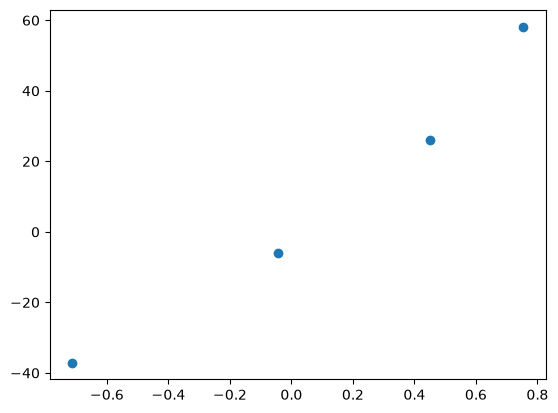

In [3]:
plt.scatter(X,Y)

In [4]:
lr = LinearRegression()
lr.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[63.09]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.27
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [5]:
lr.coef_

array([63.08504508])

In [6]:
lr.intercept_

np.float64(3.2699541053915793)

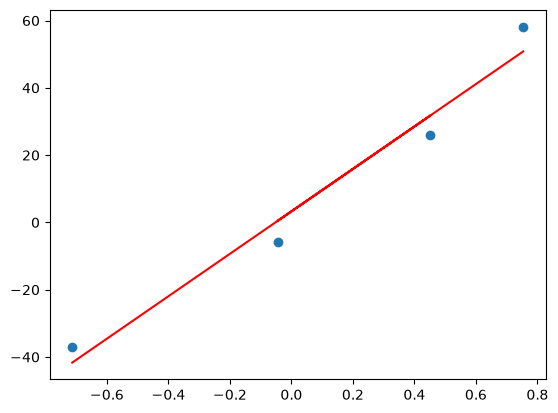

In [7]:
plt.scatter(X,Y)
plt.plot(X,lr.predict(X),color='red')

In [49]:
Y_pred = ((63.08 * X) + 100).reshape(4)

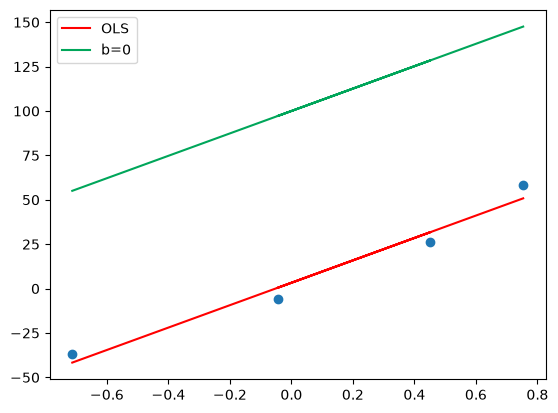

In [50]:
plt.scatter(X,Y)
plt.plot(X,lr.predict(X),color='red',label='OLS')
plt.plot(X,Y_pred,color='#00a65a',label='b=0')
plt.legend()
plt.show()

In [51]:
m = 63.08
b0=100
loss_slope = -2 * np.sum(Y-m*X.ravel() - b0)
loss_slope

np.float64(773.8358398567591)

In [52]:
rate = 0.1
step_size = loss_slope * rate
step_size

np.float64(77.38358398567591)

In [53]:
b1 = b0 - step_size
b1

np.float64(22.616416014324088)

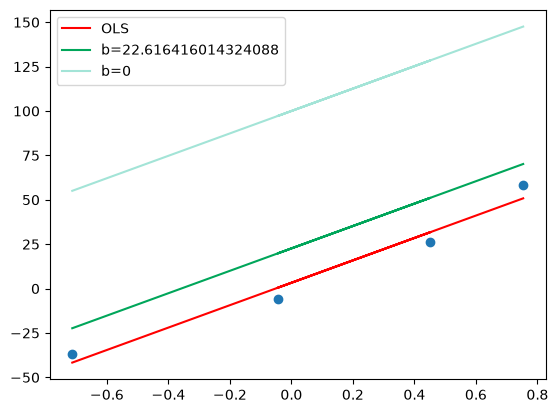

In [54]:
Y_pred1 = ((63.08 * X) + b1).reshape(4)
plt.scatter(X,Y)
plt.plot(X,lr.predict(X),color='red',label='OLS')
plt.plot(X,Y_pred1,color='#00a65a',label='b={}'.format(b1))
plt.plot(X,Y_pred,color='#A3E4D7',label='b=0')
plt.legend()
plt.show()

In [55]:
loss_slope = -2 * np.sum(Y-m*X.ravel() - b1)
loss_slope

np.float64(154.76716797135174)

In [56]:
step_size = loss_slope * rate
step_size

np.float64(15.476716797135175)

In [57]:
b2 = b1 - step_size
b2

np.float64(7.139699217188912)

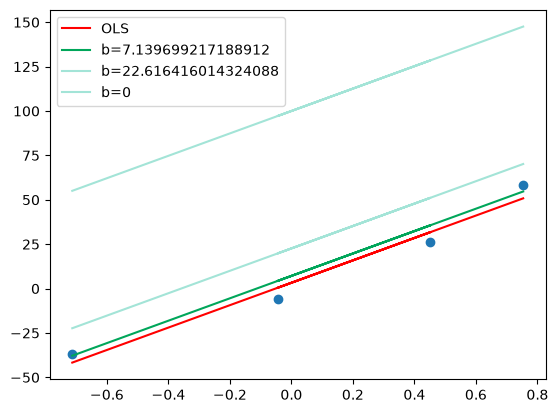

In [58]:
Y_pred2 = ((63.08 * X) + b2).reshape(4)
plt.scatter(X,Y)
plt.plot(X,lr.predict(X),color='red',label='OLS')
plt.plot(X,Y_pred2,color='#00a65a',label='b={}'.format(b2))
plt.plot(X,Y_pred1,color='#A3E4D7',label='b={}'.format(b1))
plt.plot(X,Y_pred,color='#A3E4D7',label='b=0')
plt.legend()
plt.show()

In [59]:
loss_slope = (-2) * np.sum(Y-m*X.ravel() - b2)
loss_slope

np.float64(30.953433594270322)

In [60]:
step_size = loss_slope * rate
step_size

np.float64(3.0953433594270323)

In [61]:
b3 = b2 - step_size
b3

np.float64(4.044355857761881)

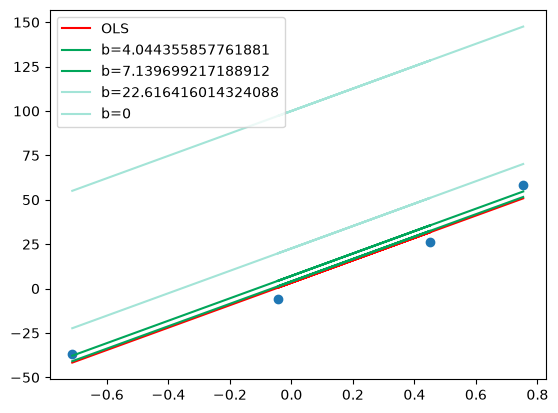

In [62]:
Y_pred3 = ((63.08 * X) + b3).reshape(4)
plt.scatter(X,Y)
plt.plot(X,lr.predict(X),color='red',label='OLS')
plt.plot(X,Y_pred3,color='#00a65a',label='b={}'.format(b3))
plt.plot(X,Y_pred2,color='#00a65a',label='b={}'.format(b2))
plt.plot(X,Y_pred1,color='#A3E4D7',label='b={}'.format(b1))
plt.plot(X,Y_pred,color='#A3E4D7',label='b=0')
plt.legend()
plt.show()

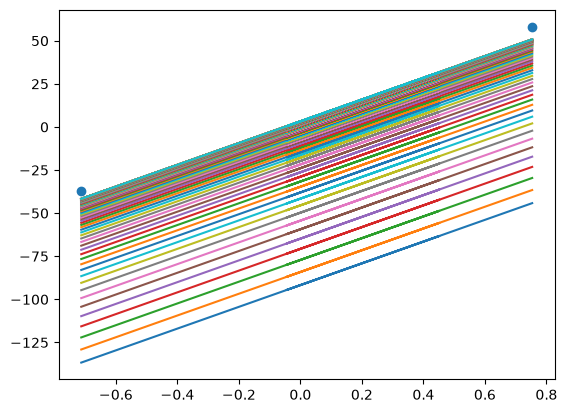

In [67]:
b = -100
m = 63.08
rate = 0.01

epochs = 100

for i in range(epochs):
    loss_slope = (-2) * np.sum(Y-m*X.ravel() - b)
    b = b - ( rate * loss_slope) 
    Y_pred = m * X + b
    plt.plot(X,Y_pred)

plt.scatter(X,Y)